<a href="https://colab.research.google.com/github/Ashu1631-web/Premium_Health/blob/main/Health_Premium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
data = pd.read_csv('/content/Health_insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
data.duplicated().sum()

np.int64(1)

In [10]:
data.shape

(1338, 7)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
import plotly.express as px
data = data
figure = px.histogram(data, x = 'sex', color = 'smoker', title = 'Sex vs Smoker')
figure.show()

In [13]:
data["sex"] = data["sex"].map({"female": 0, "male": 1})
data["smoker"] = data["smoker"].map({"no": 0, "yes": 1})
print(data.head())

   age  sex     bmi  children  smoker     region      charges
0   19    0  27.900         0       1  southwest  16884.92400
1   18    1  33.770         1       0  southeast   1725.55230
2   28    1  33.000         3       0  southeast   4449.46200
3   33    1  22.705         0       0  northwest  21984.47061
4   32    1  28.880         0       0  northwest   3866.85520


In [14]:
pie = data['region'].value_counts()
regions = pie.index
population = pie.values
figure = px.pie(data, values = population, names = regions, hole = 0.2)
figure.show()

In [15]:
data = pd.get_dummies(data, columns=['region'], drop_first=True)
print(data.corr())

                       age       sex       bmi  children    smoker   charges  \
age               1.000000 -0.020856  0.109272  0.042469 -0.025019  0.299008   
sex              -0.020856  1.000000  0.046371  0.017163  0.076185  0.057292   
bmi               0.109272  0.046371  1.000000  0.012759  0.003750  0.198341   
children          0.042469  0.017163  0.012759  1.000000  0.007673  0.067998   
smoker           -0.025019  0.076185  0.003750  0.007673  1.000000  0.787251   
charges           0.299008  0.057292  0.198341  0.067998  0.787251  1.000000   
region_northwest -0.000407 -0.011156 -0.135996  0.024806 -0.036945 -0.039905   
region_southeast -0.011642  0.017117  0.270025 -0.023066  0.068498  0.073982   
region_southwest  0.010016 -0.004184 -0.006205  0.021914 -0.036945 -0.043210   

                  region_northwest  region_southeast  region_southwest  
age                      -0.000407         -0.011642          0.010016  
sex                      -0.011156          0.017117 

In [16]:
x = np.array(data[["age", "sex", "bmi", "smoker"]])
y = np.array(data["charges"])

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
forest.fit(xtrain, ytrain)

RandomForestRegressor()

In [18]:
ypred = forest.predict(xtest)
data = pd.DataFrame(data={"Predicted Premium Amount": ypred})
print(data.head())

   Predicted Premium Amount
0              11015.202556
1               5348.487602
2              28414.054698
3               9779.780312
4              34799.999318


In [19]:
bar = px.bar(data, x =regions, y = population, title = 'Region vs Population', color = regions, text_auto = True)
bar.show()

In [20]:
line = px.line(data, x =regions, y = population, title = 'Region vs Population', color = regions, markers = True)
line.show()

## Distribution of charges (Histogram)

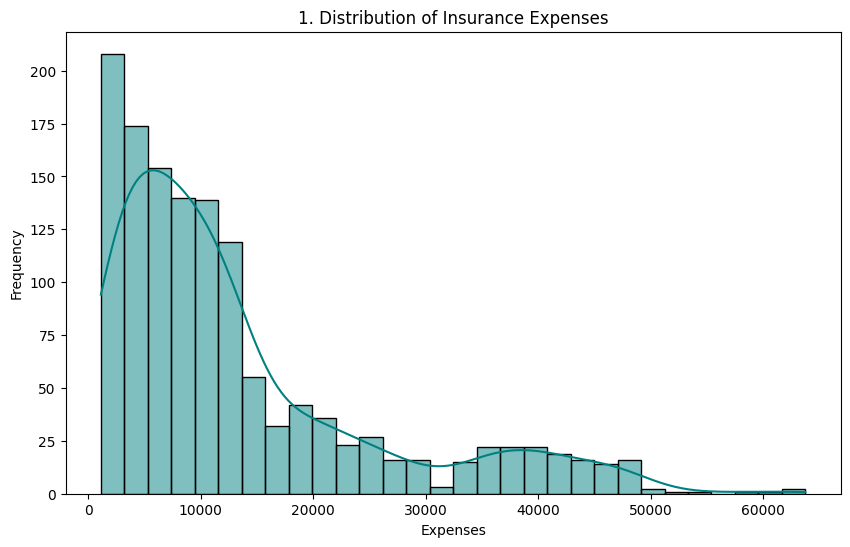

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, color='teal')
plt.title('1. Distribution of Insurance Expenses')
plt.xlabel('Expenses')
plt.ylabel('Frequency')
plt.show()

## BMI Vs charges (Scatter Plot)

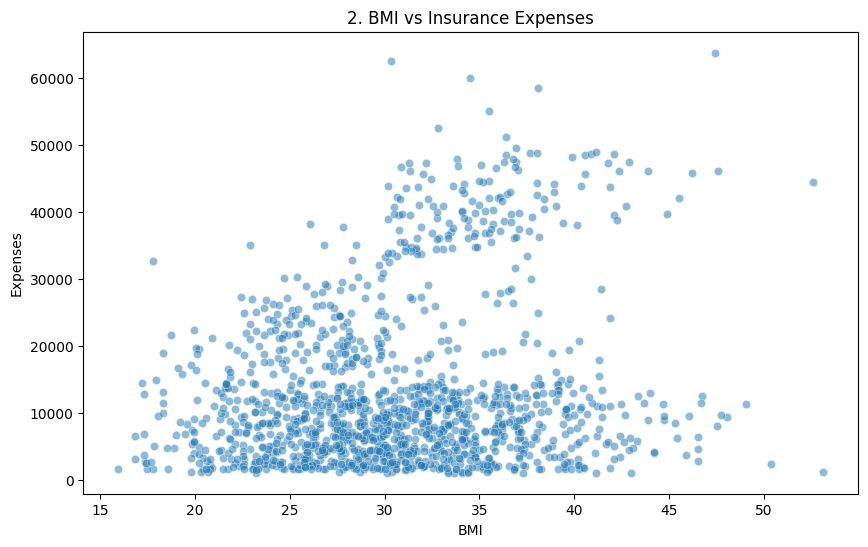

In [22]:
plot_data_for_bmi_charges = pd.DataFrame({'bmi': x[:, 2], 'charges': y})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data_for_bmi_charges, x='bmi', y='charges', alpha=0.5) # Changed 'expenses' to 'charges' and 'data' to plot_data_for_bmi_charges
plt.title('2. BMI vs Insurance Expenses')
plt.xlabel('BMI')
plt.ylabel('Expenses') # Keep as 'Expenses' for presentation, though the data column is 'charges'
plt.show()

## Smoker Vs Charged

/tmp/ipykernel_206/3521757704.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




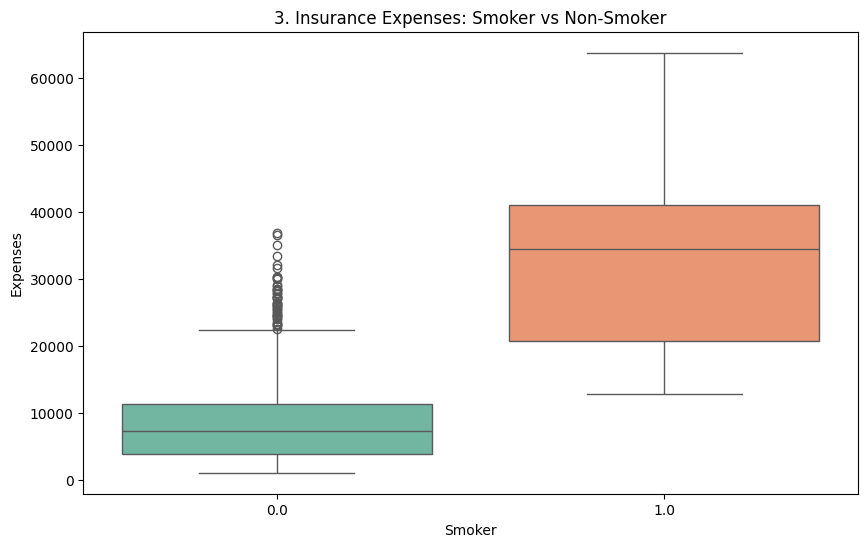

In [23]:
plot_data_for_smoker_charges = pd.DataFrame({'smoker': x[:, 3], 'charges': y})

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data_for_smoker_charges, x='smoker', y='charges', palette='Set2')
plt.title('3. Insurance Expenses: Smoker vs Non-Smoker')
plt.xlabel('Smoker')
plt.ylabel('Expenses')
plt.show()

## Age Vs Charged

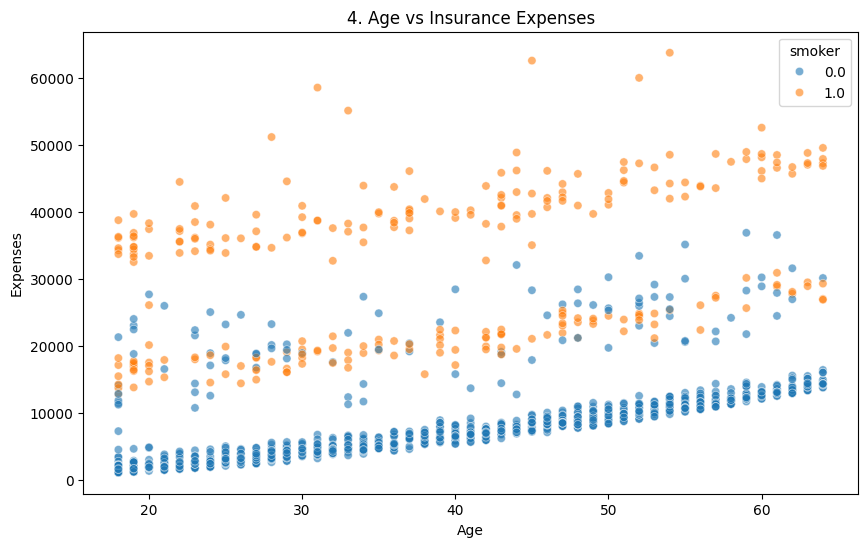

In [24]:
plot_data_for_age_charges = pd.DataFrame({'age': x[:, 0], 'smoker': x[:, 3], 'charges': y})

plt.figure(figsize=(10, 6))
# Using hue to show the impact of smoking status on age/cost
sns.scatterplot(data=plot_data_for_age_charges, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('4. Age vs Insurance Expenses')
plt.xlabel('Age')
plt.ylabel('Expenses')
plt.savefig('plot_4_age_vs_expenses.png')

## Region Wise Analysis

/tmp/ipykernel_206/3169366742.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




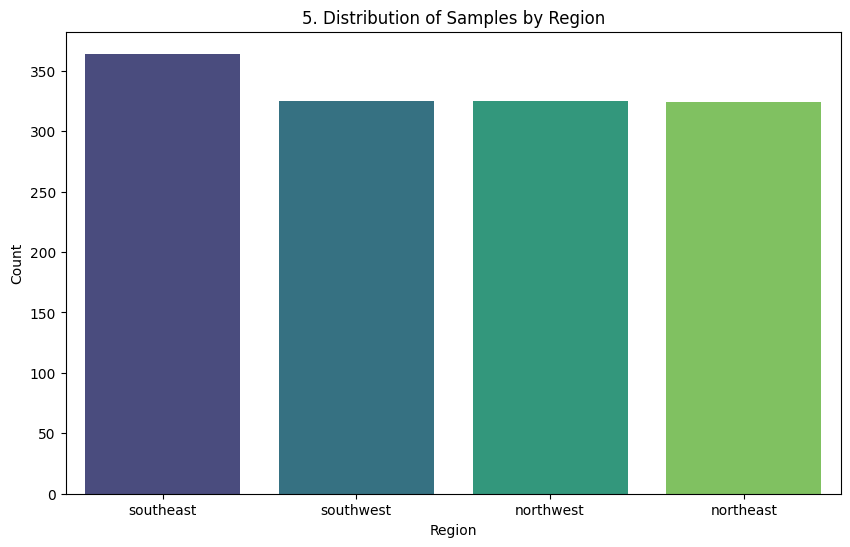

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(x=regions, y=population, palette='viridis')
plt.title('5. Distribution of Samples by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

## Correlation Heatmap

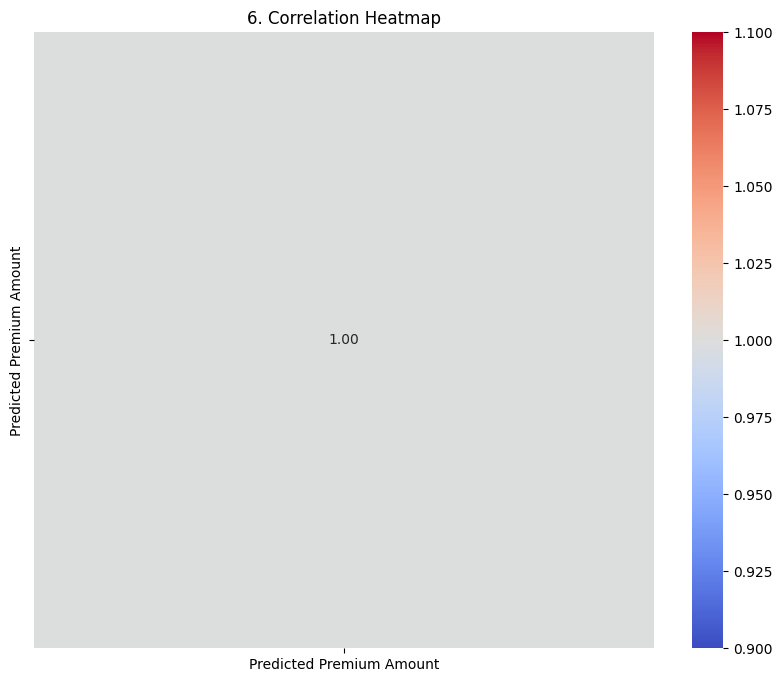

In [28]:
plt.figure(figsize=(10, 8))

# Using the data DataFrame which contains the necessary numerical columns
# for age, sex, bmi, smoker, and charges, and the one-hot encoded regions.
corr = data.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('6. Correlation Heatmap')
plt.show()

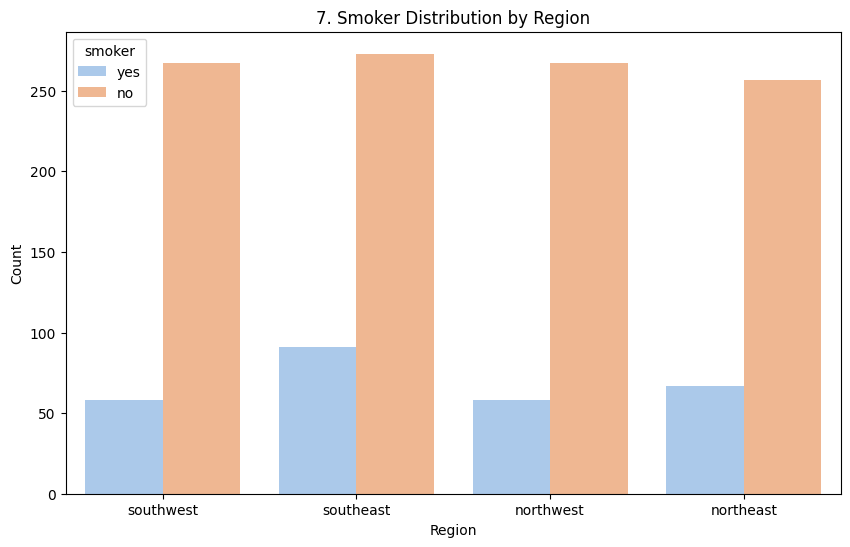

In [29]:
# Reload the original data as the 'data' variable has been transformed
original_data = pd.read_csv('/content/Health_insurance.csv')

plt.figure(figsize=(10,6))
sns.countplot(data=original_data, x='region', hue='smoker', palette='pastel')
plt.title('7. Smoker Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

## BMI Distribution By Region

/tmp/ipykernel_206/242856377.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




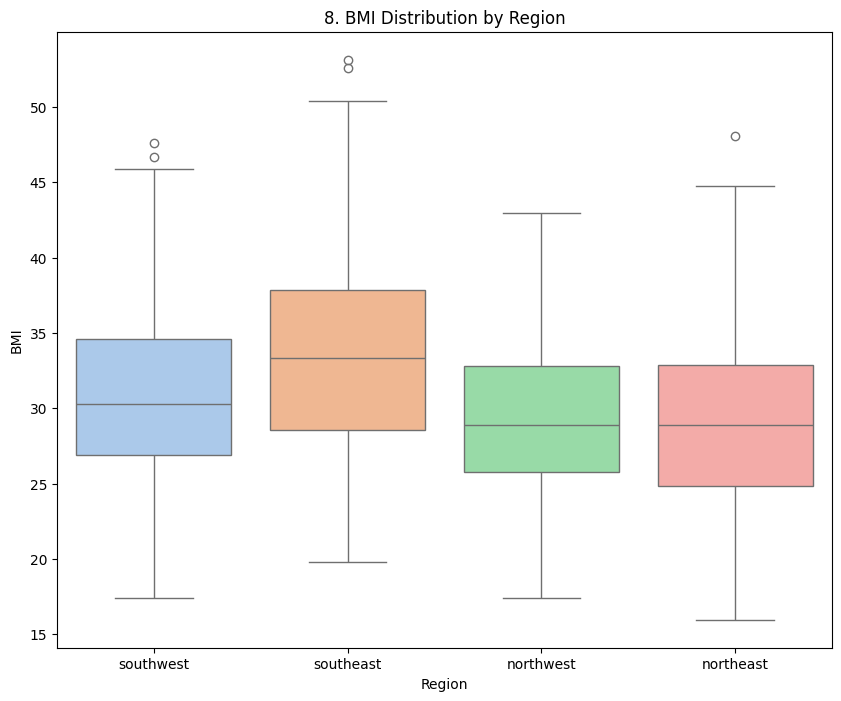

In [30]:
plt.figure(figsize=(10,8))
sns.boxplot(x='region', y='bmi', data=original_data, palette='pastel')
plt.title ('8. BMI Distribution by Region')
plt.xlabel('Region')
plt.ylabel('BMI')
plt.show()

## Region Vs Children Plot

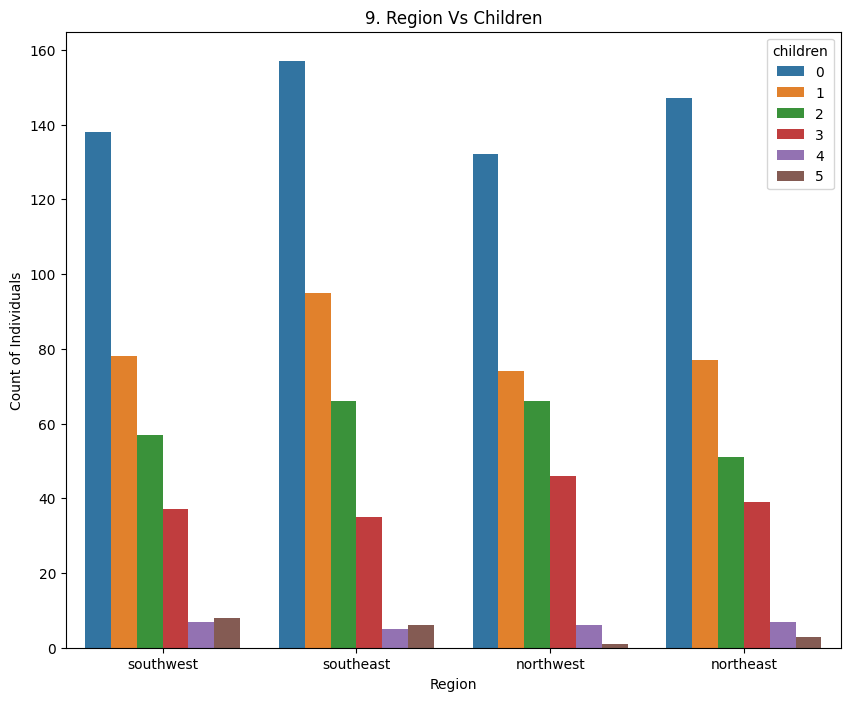

In [31]:
plt.figure(figsize=(10,8))
sns.countplot(data=original_data, x='region', hue='children', palette='tab10')
plt.title('9. Region Vs Children')
plt.xlabel('Region')
plt.ylabel('Count of Individuals')
plt.show()